# ENV Setup

### Import module

In [1]:
import os, random, math
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

### Set seed

In [2]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

SEED = 42
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.9.0+cu126


# Data Load & Preprocess

### Import dataset

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/phucthaiv02/butterfly-image-classification/Training_set.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/phucthaiv02/butterfly-image-classification/Testing_set.csv")

print("train_df shape:", train_df.shape)
print("test_df shape :", test_df.shape)
print("train_df columns:", train_df.columns.tolist())
print("test_df columns :", test_df.columns.tolist())

train_df shape: (6499, 2)
test_df shape : (2786, 1)
train_df columns: ['filename', 'label']
test_df columns : ['filename']


In [4]:
display(train_df.head())
display(test_df.head())

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART


,filename
0,Image_1.jpg
1,Image_2.jpg
2,Image_3.jpg
3,Image_4.jpg
4,Image_5.jpg


In [5]:
def infer_col(cols, keys):
    cols_l = {c.lower(): c for c in cols}
    for k in keys:
        for c_low, c in cols_l.items():
            if k in c_low:
                return c
    return None

fname_col = infer_col(train_df.columns, keys=["filename", "file", "image", "path"])
label_col = infer_col(train_df.columns, keys=["label", "class", "species", "category", "name"])

if fname_col is None:
    fname_col = train_df.columns[0]
if label_col is None:
    label_col = train_df.columns[1] if len(train_df.columns) > 1 else None

print("Inferred fname_col:", fname_col)
print("Inferred label_col:", label_col)

Inferred fname_col: filename
Inferred label_col: label


### Missing file check

In [6]:
TRAIN_DIR = Path("/kaggle/input/datasets/phucthaiv02/butterfly-image-classification/train")
TEST_DIR = Path("/kaggle/input/datasets/phucthaiv02/butterfly-image-classification/test")

missing = 0
for fn in train_df[fname_col].astype(str).sample(min(50, len(train_df)), random_state=SEED):
    if not (TRAIN_DIR / fn).exists():
        missing += 1
print(f"Sample missing files in train (out of 50): {missing}")

Sample missing files in train (out of 50): 0


In [7]:
print("n_classes:", train_df[label_col].nunique())
print("Top labels:\n", train_df[label_col].value_counts().head(10))

n_classes: 75
Top labels:
 label
MOURNING CLOAK              131
SLEEPY ORANGE               107
ATALA                       100
BROWN SIPROETA               99
SCARCE SWALLOW               97
CRECENT                      97
BANDED ORANGE HELICONIAN     97
MILBERTS TORTOISESHELL       96
RED CRACKER                  96
ORANGE TIP                   96
Name: count, dtype: int64


### Label encoding

In [8]:
# label encoding
labels = sorted(train_df[label_col].unique().tolist())
label2idx = {l:i for i,l in enumerate(labels)}
idx2label = {i:l for l,i in label2idx.items()}

train_df = train_df.copy()
train_df["label_idx"] = train_df[label_col].map(label2idx).astype(int)

print("Example mapping:", list(label2idx.items())[:5])

Example mapping: [('ADONIS', 0), ('AFRICAN GIANT SWALLOWTAIL', 1), ('AMERICAN SNOOT', 2), ('AN 88', 3), ('APPOLLO', 4)]


### Stratified split

In [9]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
X = train_df[fname_col].astype(str).values
y = train_df["label_idx"].values

train_idx, val_idx = next(sss.split(X, y))
df_tr = train_df.iloc[train_idx].reset_index(drop=True)
df_va = train_df.iloc[val_idx].reset_index(drop=True)

print("Train size:", len(df_tr), "Val size:", len(df_va))
print("Train class count min/max:", df_tr["label_idx"].value_counts().min(), df_tr["label_idx"].value_counts().max())
print("Val class count min/max  :", df_va["label_idx"].value_counts().min(), df_va["label_idx"].value_counts().max())

Train size: 5199 Val size: 1300
Train class count min/max: 57 105
Val class count min/max  : 14 26


In [10]:
missing_in_val = set(df_tr["label_idx"].unique()) - set(df_va["label_idx"].unique())
print("Classes missing in val:", len(missing_in_val))

Classes missing in val: 0


### Data transform

In [11]:
import torchvision.transforms as T

IMG_SIZE = 299
BATCH_SIZE = 64
NUM_WORKERS = 2

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
])

class ButterflyDataset(Dataset):
    def __init__(self, df, img_dir, fname_col, label_col_idx=None, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.fname_col = fname_col
        self.label_col_idx = label_col_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        fn = str(row[self.fname_col])
        path = self.img_dir / fn
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.label_col_idx is None:
            return img, fn
        y = int(row[self.label_col_idx])
        return img, y

ds_tr = ButterflyDataset(df_tr, TRAIN_DIR, fname_col=fname_col, label_col_idx="label_idx", transform=train_tfms)
ds_va = ButterflyDataset(df_va, TRAIN_DIR, fname_col=fname_col, label_col_idx="label_idx", transform=val_tfms)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

xb, yb = next(iter(dl_tr))
print("Batch x:", xb.shape, xb.dtype, " | Batch y:", yb.shape, yb.dtype)
print("y sample:", yb[:10].tolist())

Batch x: torch.Size([64, 3, 299, 299]) torch.float32  | Batch y: torch.Size([64]) torch.int64
y sample: [40, 20, 1, 46, 41, 36, 38, 28, 5, 23]


# Architecture & Training

### Simple CNN architecture

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            block(3, 32),     # 224 -> 112
            block(32, 64),    # 112 -> 56
            block(64, 128),   # 56  -> 28
            block(128, 256),  # 28  -> 14
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

num_classes = len(labels)
model = SimpleCNN(num_classes=num_classes).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("num_classes:", num_classes)
print("params:", n_params, "| trainable:", n_trainable)

with torch.no_grad():
    out = model(xb.to(device))
print("logits:", out.shape)

num_classes: 75
params: 1192491 | trainable: 1192491
logits: torch.Size([64, 75])


In [13]:
EPOCHS = 35
LR = 5e-4
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [14]:
def train_one_epoch(model, loader):
    model.train()
    losses, preds_all, y_all = [], [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        preds_all.append(preds.detach().cpu().numpy())
        y_all.append(y.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    y_all = np.concatenate(y_all)
    acc = (preds_all == y_all).mean()
    f1m = f1_score(y_all, preds_all, average="macro")
    return float(np.mean(losses)), float(acc), float(f1m)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    losses, preds_all, y_all = [], [], []
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)

        losses.append(loss.item())
        preds = logits.argmax(dim=1)
        preds_all.append(preds.detach().cpu().numpy())
        y_all.append(y.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    y_all = np.concatenate(y_all)
    acc = (preds_all == y_all).mean()
    f1m = f1_score(y_all, preds_all, average="macro")
    return float(np.mean(losses)), float(acc), float(f1m), y_all, preds_all

history = {"tr_loss":[], "tr_acc":[], "tr_f1m":[], "va_loss":[], "va_acc":[], "va_f1m":[]}
best_va_f1 = -1.0
best_path = Path("/kaggle/working/best_cnn_from_scratch.pt")

### Training

In [15]:
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc, tr_f1m = train_one_epoch(model, dl_tr)
    va_loss, va_acc, va_f1m, y_true, y_pred = eval_one_epoch(model, dl_va)
    scheduler.step()

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc); history["tr_f1m"].append(tr_f1m)
    history["va_loss"].append(va_loss); history["va_acc"].append(va_acc); history["va_f1m"].append(va_f1m)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | lr={lr_now:.2e} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} tr_f1m={tr_f1m:.4f} | "
          f"va_loss={va_loss:.4f} va_acc={va_acc:.4f} va_f1m={va_f1m:.4f}")

    if va_f1m > best_va_f1:
        best_va_f1 = va_f1m
        torch.save({"model": model.state_dict(),
                    "label2idx": label2idx,
                    "idx2label": idx2label,
                    "img_size": IMG_SIZE}, best_path)
        print("  𖦹 Saved best:", best_path, "| best_va_f1m:", best_va_f1)

Epoch 01/35 | lr=4.99e-04 | tr_loss=3.9844 tr_acc=0.1039 tr_f1m=0.0599 | va_loss=3.6687 va_acc=0.1500 va_f1m=0.0796
  𖦹 Saved best: /kaggle/working/best_cnn_from_scratch.pt | best_va_f1m: 0.07964212415449914
Epoch 02/35 | lr=4.96e-04 | tr_loss=3.4119 tr_acc=0.1804 tr_f1m=0.1220 | va_loss=3.1592 va_acc=0.2454 va_f1m=0.1828
  𖦹 Saved best: /kaggle/working/best_cnn_from_scratch.pt | best_va_f1m: 0.18277647486177412
Epoch 03/35 | lr=4.91e-04 | tr_loss=2.9953 tr_acc=0.2827 tr_f1m=0.2323 | va_loss=2.9443 va_acc=0.3331 va_f1m=0.2833
  𖦹 Saved best: /kaggle/working/best_cnn_from_scratch.pt | best_va_f1m: 0.2833309527114465
Epoch 04/35 | lr=4.84e-04 | tr_loss=2.7039 tr_acc=0.3495 tr_f1m=0.3071 | va_loss=2.6395 va_acc=0.3531 va_f1m=0.3051
  𖦹 Saved best: /kaggle/working/best_cnn_from_scratch.pt | best_va_f1m: 0.30505328499064743
Epoch 05/35 | lr=4.75e-04 | tr_loss=2.4329 tr_acc=0.4049 tr_f1m=0.3677 | va_loss=2.4871 va_acc=0.4138 va_f1m=0.3864
  𖦹 Saved best: /kaggle/working/best_cnn_from_scratch

# Evaluation

### Plot learning curves

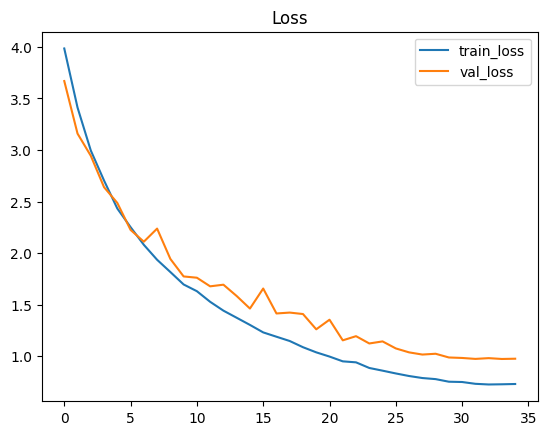

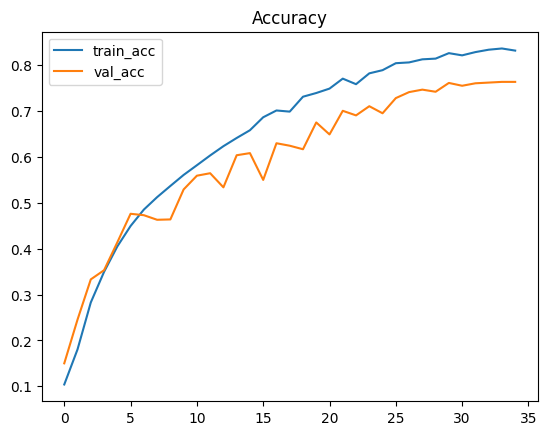

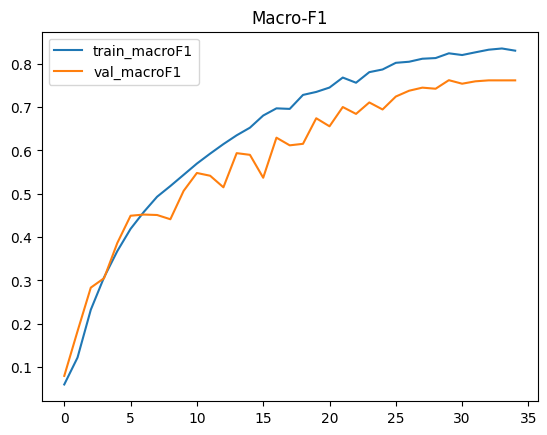

In [16]:
plt.figure()
plt.plot(history["tr_loss"], label="train_loss")
plt.plot(history["va_loss"], label="val_loss")
plt.legend(); plt.title("Loss"); plt.show()

plt.figure()
plt.plot(history["tr_acc"], label="train_acc")
plt.plot(history["va_acc"], label="val_acc")
plt.legend(); plt.title("Accuracy"); plt.show()

plt.figure()
plt.plot(history["tr_f1m"], label="train_macroF1")
plt.plot(history["va_f1m"], label="val_macroF1")
plt.legend(); plt.title("Macro-F1"); plt.show()

In [17]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])

va_loss, va_acc, va_f1m, y_true, y_pred = eval_one_epoch(model, dl_va)
print("Best checkpoint val metrics:")
print("val_loss:", va_loss, "val_acc:", va_acc, "val_macroF1:", va_f1m)

Best checkpoint val metrics:
val_loss: 0.9888352297601246 val_acc: 0.7615384615384615 val_macroF1: 0.7620282912649843


### Classification report

In [18]:
target_names = [idx2label[i] for i in range(num_classes)]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

                           precision    recall  f1-score   support

                   ADONIS     0.7895    0.8333    0.8108        18
AFRICAN GIANT SWALLOWTAIL     0.7500    0.8000    0.7742        15
           AMERICAN SNOOT     0.9091    0.6667    0.7692        15
                    AN 88     1.0000    0.8824    0.9375        17
                  APPOLLO     0.7143    0.8333    0.7692        18
                    ATALA     1.0000    0.9500    0.9744        20
 BANDED ORANGE HELICONIAN     0.9474    0.9000    0.9231        20
           BANDED PEACOCK     0.8000    0.7059    0.7500        17
            BECKERS WHITE     0.3889    0.4375    0.4118        16
         BLACK HAIRSTREAK     1.0000    0.5294    0.6923        17
              BLUE MORPHO     0.8333    0.6667    0.7407        15
        BLUE SPOTTED CROW     0.7500    0.8824    0.8108        17
           BROWN SIPROETA     0.8421    0.8000    0.8205        20
            CABBAGE WHITE     0.7273    0.8889    0.8000     

### Confusion matrix

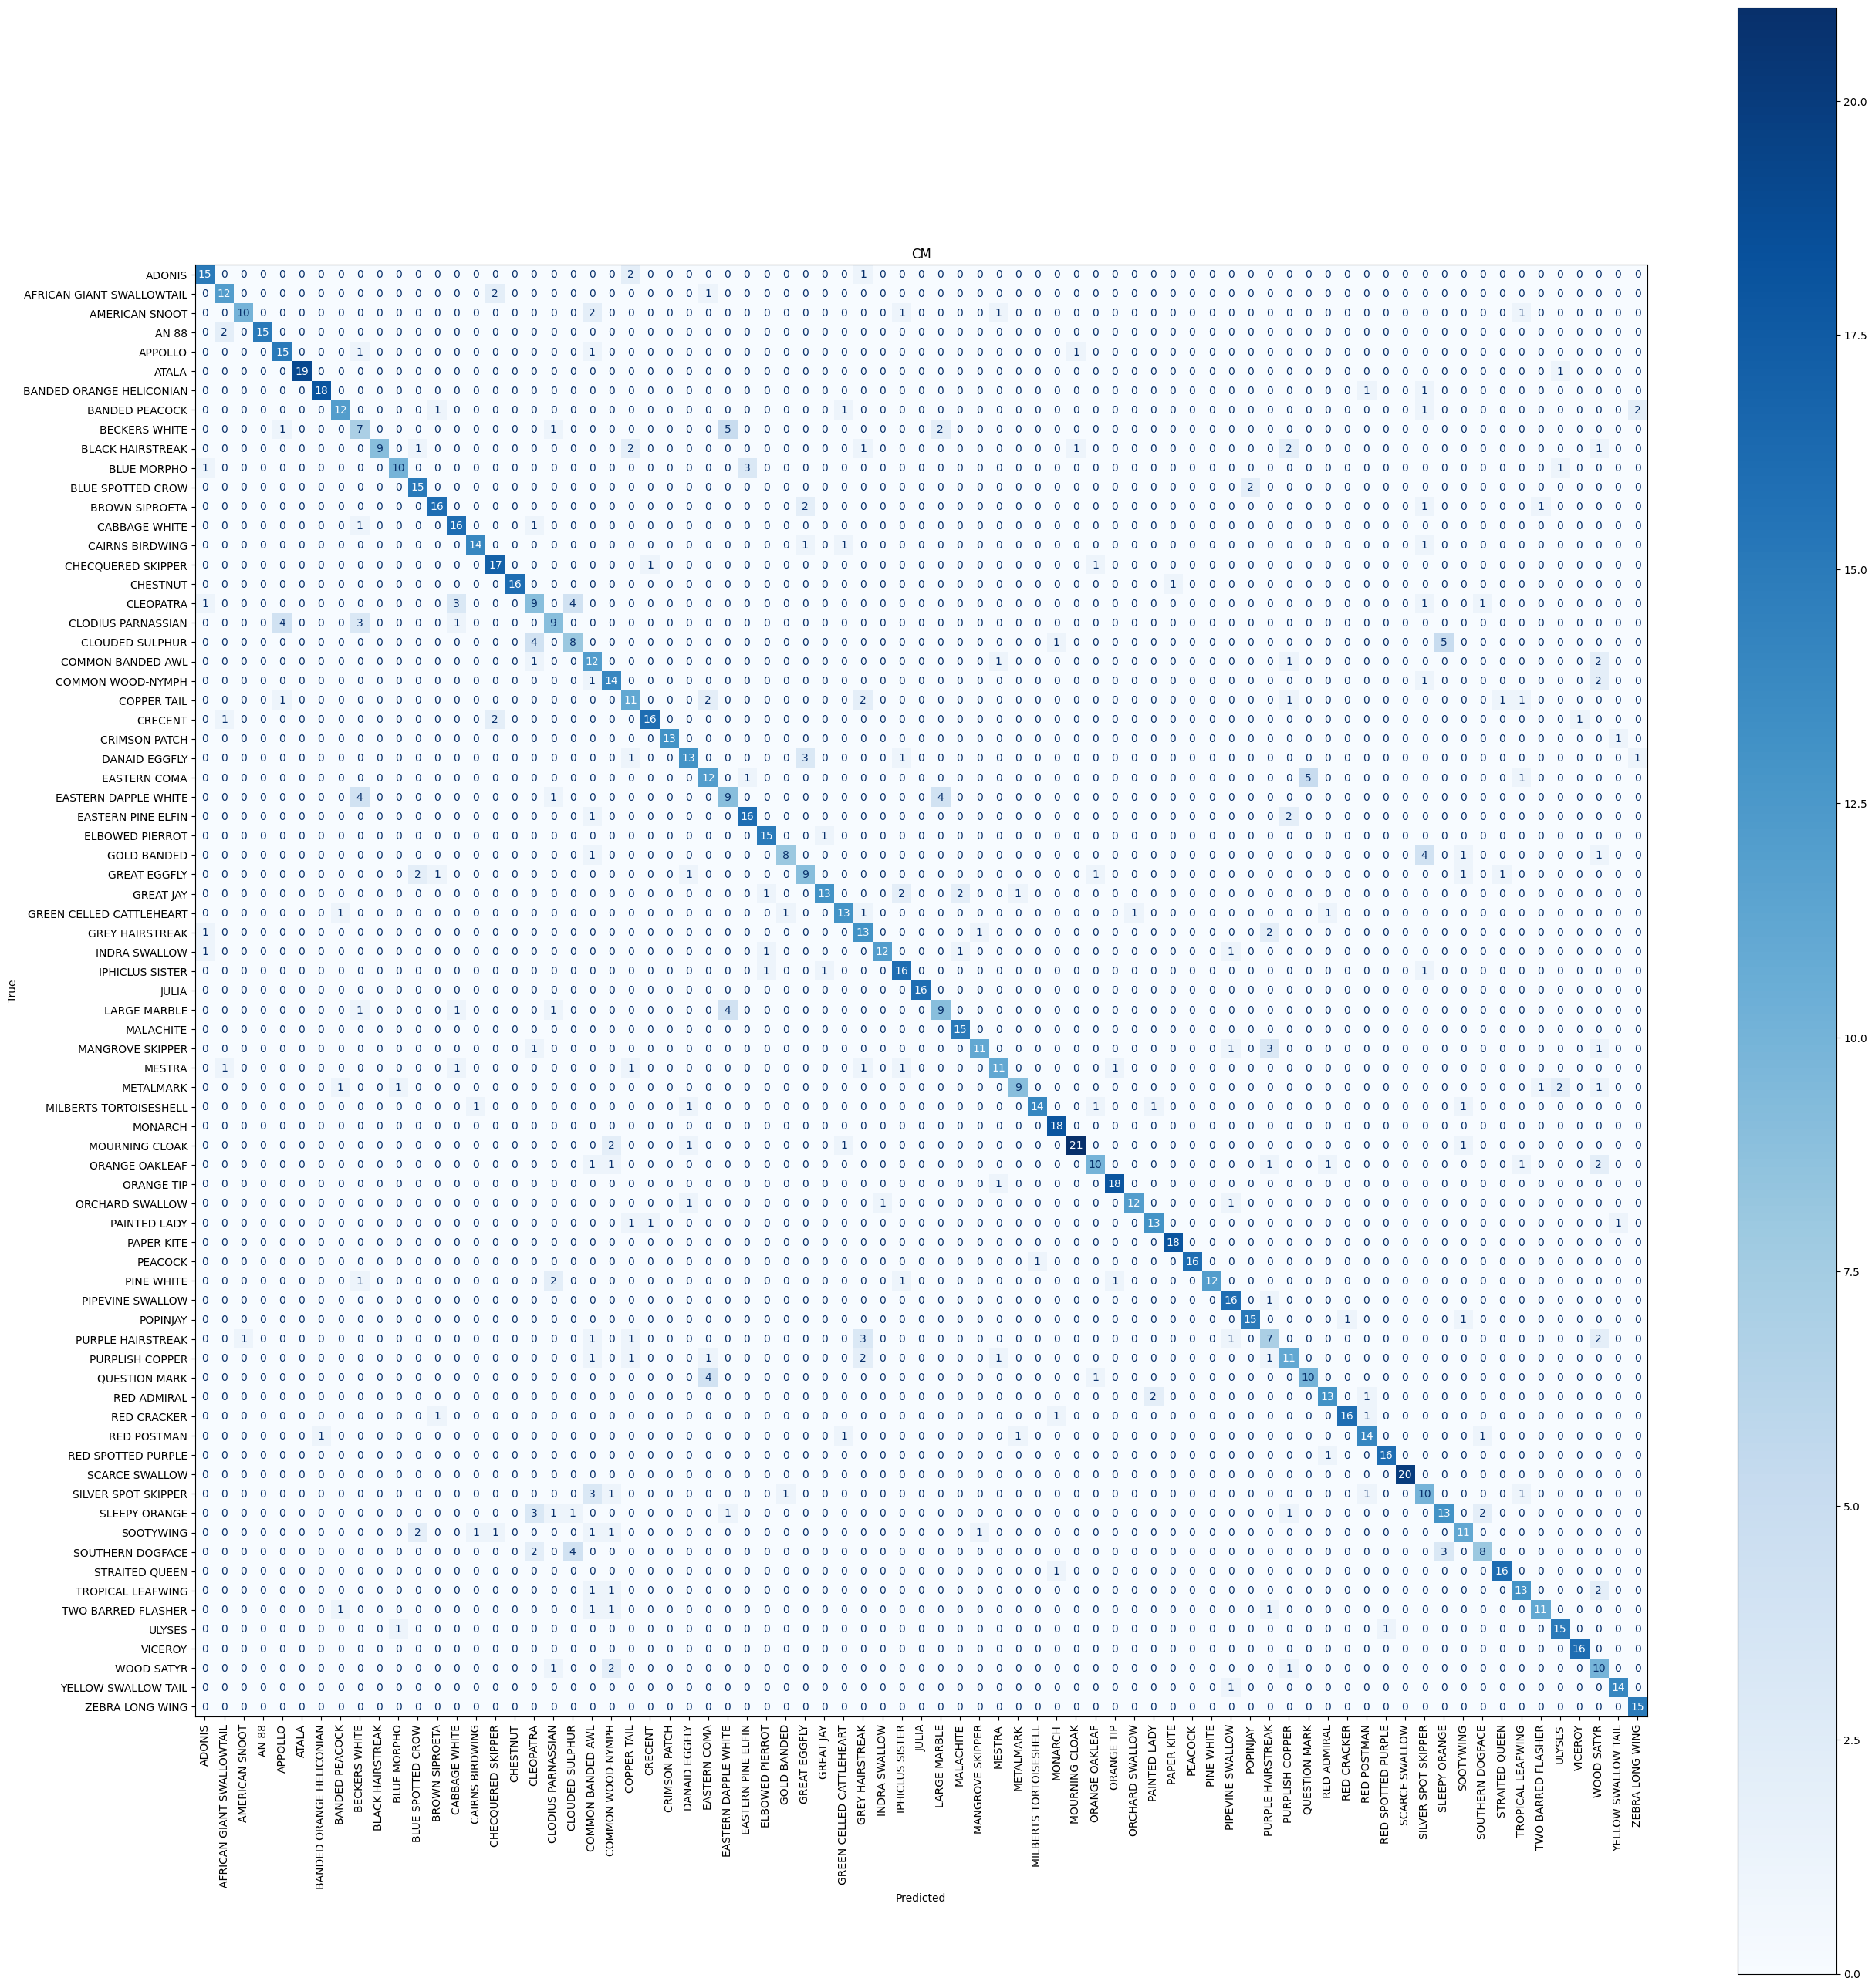

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confmat_matplotlib(
    y_true,
    y_pred,
    class_names=None,
    normalize=None,
    max_figsize=30,
    xticks_rotation=90,
    cmap="Blues",
    title="Confusion Matrix"
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if class_names is not None:
        labels = np.arange(len(class_names))
        display_labels = class_names
    else:
        labels = None
        display_labels = None

    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)

    n = cm.shape[0]
    size = min(max_figsize, max(10, 0.35 * n))
    fig, ax = plt.subplots(figsize=(size, size))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(
        ax=ax,
        cmap=cmap,
        colorbar=True,
        xticks_rotation=xticks_rotation,
        values_format=".2f" if normalize else "d",
        include_values=True
    )

    ax.set_title(title + (f" (normalize={normalize})" if normalize else ""))
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

class_names = [idx2label[i] for i in range(num_classes)]
plot_confmat_matplotlib(y_true, y_pred, class_names=class_names, normalize=None, title="CM")